In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接数据库
conn = sqlite3.connect('movies.db')

# 读入原始电影数据
df = pd.read_excel(r'D:\Projects\douban-movie\国产电影数据集.xlsx')
print("数据形状:", df.shape)
print("列名:", df.columns.tolist())


数据形状: (120, 24)
列名: ['电影名称', '导演', '主演', '作品类型', '电影时长', '电影版本', '点映日期', '最晚结束日期', '最新上映天数', '正式上映日期', '数据截止日期', '点映天数', '点映票房', '累计票房', '累计场次', '累计人次', '第一天观看人次', '首映票房', '首周票房', '首周末票房', '猫眼想看人数', '淘票票想看人数', '猫眼评分', '豆瓣评分']


In [2]:
# === 数据清洗 + 导入 SQLite ===

# 1. 选需要的列，处理缺失
df_clean = df[['电影名称', '导演', '作品类型', '电影时长', '累计票房', '豆瓣评分', '猫眼评分', '累计人次', '猫眼想看人数', '正式上映日期']].copy()

# 2. 票房单位转为亿（方便看）
df_clean['累计票房_亿'] = (df_clean['累计票房'] / 1e8).round(2)
df_clean['累计人次_万'] = (df_clean['累计人次'] / 1e4).round(0).astype(int)

# 3. 存入 SQLite
conn.execute('DROP TABLE IF EXISTS movies')
df_clean.to_sql('movies', conn, index=False)

# 4. 拆散作品类型，存入另一张表
rows = []
for i, row in df_clean.iterrows():
    for t in row['作品类型'].split(','):
        rows.append({
            '电影名称': row['电影名称'],
            '类型': t.strip(),
            '豆瓣评分': row['豆瓣评分'],
            '累计票房_亿': row['累计票房_亿']
        })

df_type = pd.DataFrame(rows)
conn.execute('DROP TABLE IF EXISTS movie_types')
df_type.to_sql('movie_types', conn, index=False)

# 验证
n_movies = pd.read_sql("SELECT COUNT(*) FROM movies", conn).values[0][0]
n_types = pd.read_sql("SELECT COUNT(*) FROM movie_types", conn).values[0][0]
print(f"movies 表: {n_movies} 部电影")
print(f"movie_types 表: {n_types} 条类型记录")

print("\n=== 电影表前3行 ===")
print(pd.read_sql("SELECT 电影名称, 豆瓣评分, 猫眼评分, 累计票房_亿 FROM movies LIMIT 3", conn))
print("\n=== 类型表前10行 ===")
print(pd.read_sql("SELECT * FROM movie_types LIMIT 10", conn))


movies 表: 120 部电影
movie_types 表: 261 条类型记录

=== 电影表前3行 ===
      电影名称  豆瓣评分  猫眼评分  累计票房_亿
0  哪吒之魔童闹海   8.3   9.3  151.88
1      长津湖   7.3   9.3   56.75
2      战狼2   7.2   9.8   56.07

=== 类型表前10行 ===
      电影名称  类型  累计票房_亿  豆瓣评分
0  哪吒之魔童闹海  动画  151.88   8.3
1  哪吒之魔童闹海  奇幻  151.88   8.3
2  哪吒之魔童闹海  喜剧  151.88   8.3
3      长津湖  战争   56.75   7.3
4      长津湖  历史   56.75   7.3
5      长津湖  动作   56.75   7.3
6      战狼2  动作   56.07   7.2
7      战狼2  战争   56.07   7.2
8   你好，李焕英  剧情   53.98   7.8
9   你好，李焕英  喜剧   53.98   7.8


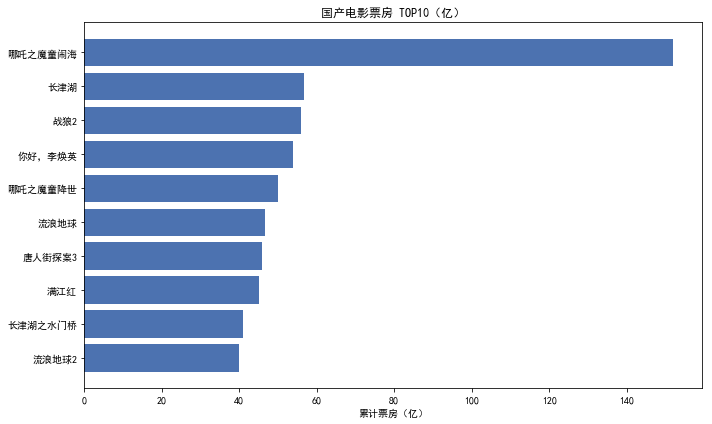

      电影名称  豆瓣评分  猫眼评分  累计票房_亿
0  哪吒之魔童闹海   8.3   9.3  151.88
1      长津湖   7.3   9.3   56.75
2      战狼2   7.2   9.8   56.07
3   你好，李焕英   7.8   9.3   53.98
4  哪吒之魔童降世   8.2   9.5   49.90
5     流浪地球   8.0   9.1   46.70
6   唐人街探案3   5.3   9.4   45.77
7      满江红   7.0   9.2   45.10
8  长津湖之水门桥   7.0   9.5   40.87
9    流浪地球2   8.1   9.2   40.05


In [3]:
# === SQL：票房前10 ===
df_top10 = pd.read_sql("""
    SELECT 电影名称, 豆瓣评分, 猫眼评分, 累计票房_亿
    FROM movies
    ORDER BY 累计票房_亿 DESC
    LIMIT 10
""", conn)

# 画图
plt.figure(figsize=(10, 6))
plt.barh(df_top10['电影名称'][::-1], df_top10['累计票房_亿'][::-1], color='#4C72B0')
plt.title('国产电影票房 TOP10（亿）')
plt.xlabel('累计票房（亿）')
plt.tight_layout()
plt.show()

print(df_top10)


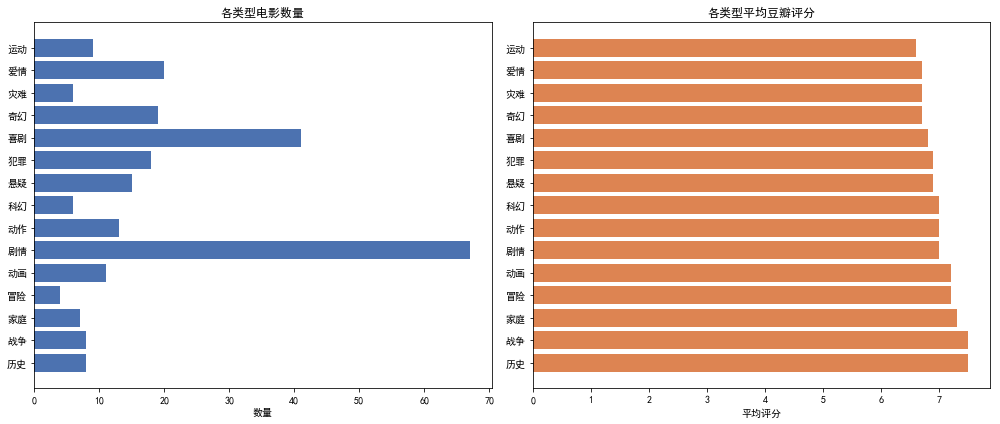

    类型  数量  平均评分
0   历史   8   7.5
1   战争   8   7.5
2   家庭   7   7.3
3   冒险   4   7.2
4   动画  11   7.2
5   剧情  67   7.0
6   动作  13   7.0
7   科幻   6   7.0
8   悬疑  15   6.9
9   犯罪  18   6.9
10  喜剧  41   6.8
11  奇幻  19   6.7
12  灾难   6   6.7
13  爱情  20   6.7
14  运动   9   6.6


In [4]:
# === SQL：各类型平均评分和数量 ===
df_type_stats = pd.read_sql("""
    SELECT 类型, COUNT(*) AS 数量, ROUND(AVG(豆瓣评分), 1) AS 平均评分
    FROM movie_types
    GROUP BY 类型
    HAVING 数量 >= 3
    ORDER BY 平均评分 DESC
""", conn)

# 画图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(df_type_stats['类型'], df_type_stats['数量'], color='#4C72B0')
axes[0].set_title('各类型电影数量')
axes[0].set_xlabel('数量')

axes[1].barh(df_type_stats['类型'], df_type_stats['平均评分'], color='#DD8452')
axes[1].set_title('各类型平均豆瓣评分')
axes[1].set_xlabel('平均评分')

plt.tight_layout()
plt.show()
print(df_type_stats)



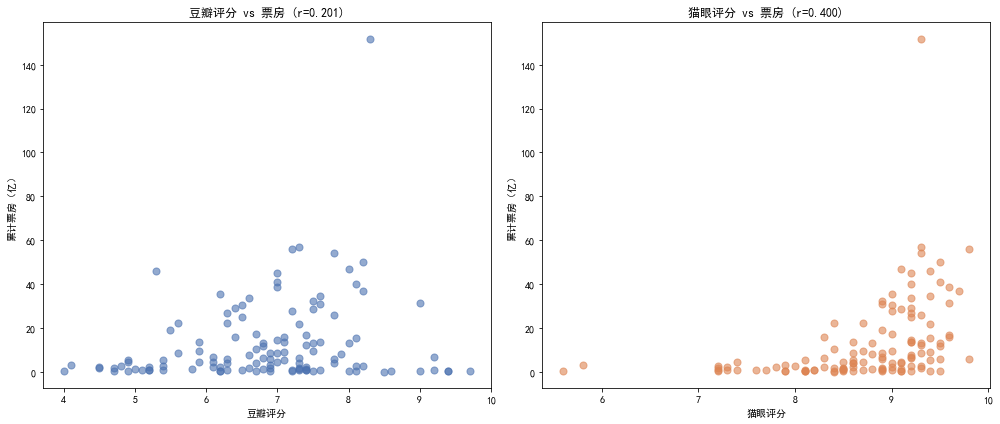

In [5]:
# === SQL：评分与票房的关系 ===
df_score = pd.read_sql("""
    SELECT 豆瓣评分, 猫眼评分, 累计票房_亿
    FROM movies
""", conn)

# 画图 + 相关系数
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df_score['豆瓣评分'], df_score['累计票房_亿'], alpha=0.6, c='#4C72B0', s=50)
axes[0].set_xlabel('豆瓣评分')
axes[0].set_ylabel('累计票房（亿）')
axes[0].set_title(f"豆瓣评分 vs 票房 (r={df_score['豆瓣评分'].corr(df_score['累计票房_亿']):.3f})")

axes[1].scatter(df_score['猫眼评分'], df_score['累计票房_亿'], alpha=0.6, c='#DD8452', s=50)
axes[1].set_xlabel('猫眼评分')
axes[1].set_ylabel('累计票房（亿）')
axes[1].set_title(f"猫眼评分 vs 票房 (r={df_score['猫眼评分'].corr(df_score['累计票房_亿']):.3f})")

plt.tight_layout()
plt.show()


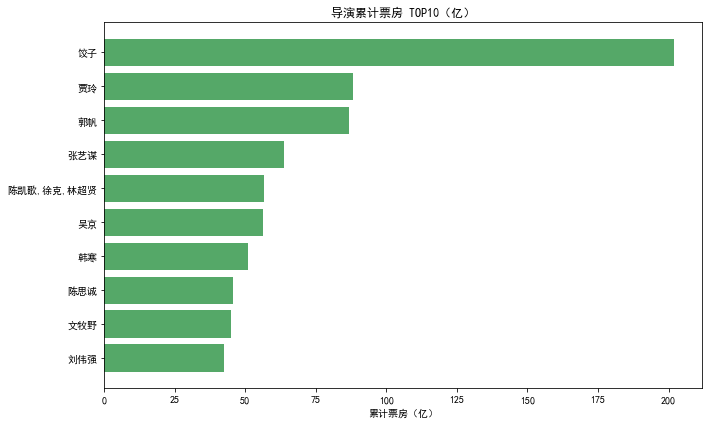

           导演  作品数  总票房_亿
0          饺子    2  201.8
1          贾玲    2   88.3
2          郭帆    2   86.7
3         张艺谋    4   63.8
4  陈凯歌,徐克,林超贤    1   56.7
5          吴京    1   56.1
6          韩寒    3   51.1
7         陈思诚    1   45.8
8         文牧野    2   44.9
9         刘伟强    2   42.4


In [6]:
# === SQL：导演累计票房 TOP10 ===
df_director = pd.read_sql("""
    SELECT 导演, COUNT(*) AS 作品数, ROUND(SUM(累计票房_亿), 1) AS 总票房_亿
    FROM movies
    GROUP BY 导演
    ORDER BY 总票房_亿 DESC
    LIMIT 10
""", conn)

plt.figure(figsize=(10, 6))
plt.barh(df_director['导演'][::-1], df_director['总票房_亿'][::-1], color='#55A868')
plt.title('导演累计票房 TOP10（亿）')
plt.xlabel('累计票房（亿）')
plt.tight_layout()
plt.show()
print(df_director)

